In [1]:
# ============================================================
# BANK MARKETING — END-TO-END ANALYSIS
# Dataset: bank-full.csv (UCI Bank Marketing Dataset)
# Sections:
#   1. Data Loading
#   2. Data Cleaning
#   3. Feature Engineering
#   4. Exploratory Data Analysis (10 plots)
#   5. Preprocessing & Train-Test Split
#   6. Modeling (Logistic Regression, RF, GBM)
#   7. Evaluation (4 plots)
# ============================================================

### Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay, average_precision_score,
    precision_recall_curve
)


> Color Pallete

In [7]:
# ─────────────────────────────────────────────────────────────
# GLOBAL PALETTE  (consistent across ALL plots)
# ─────────────────────────────────────────────────────────────
PALETTE   = ["#1b4332", "#2d6a4f", "#52b788", "#95d5b2", "#d8f3dc"]
NEG_COLOR = "#e76f51"
POS_COLOR = "#52b788"
PRIMARY   = "#1b4332"
SECONDARY = "#2d6a4f"
ACCENT    = "#95d5b2"
BG        = "#f8faf9"
GRID_C    = "#dee2e6"
FTITLE    = {"fontsize": 14, "fontweight": "bold", "color": PRIMARY}
FLABEL    = {"fontsize": 11, "color": "#343a40"}

sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG,
    "axes.edgecolor"  : GRID_C, "grid.color": GRID_C,
    "grid.linewidth"  : 0.6,    "axes.grid": True,
    "font.family"     : "DejaVu Sans",
})


> Program to save plots

In [11]:
def style_ax(ax, title, xlabel="", ylabel="", legend=True):
    """Apply consistent styling to any Axes object."""
    ax.set_title(title, **FTITLE, pad=12)
    if xlabel: ax.set_xlabel(xlabel, **FLABEL)
    if ylabel: ax.set_ylabel(ylabel, **FLABEL)
    ax.tick_params(colors="#495057", labelsize=10)
    for sp in ax.spines.values(): sp.set_visible(False)
    if legend and ax.get_legend(): ax.get_legend().set_title("")
    return ax

OUT = "./"   # folder to save plots — change as needed

### Data Loading

In [14]:
df = pd.read_csv("bank-full.csv", sep=",")
print(f"Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns : {df.columns.tolist()}")
print(df.head())

Shape   : 45,211 rows × 17 columns
Columns : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1    

### Data Cleansing

In [62]:
# ── Simpan salinan raw untuk perbandingan ──────────────────────
df_raw = df.copy()

# ── Replace 'unknown' dengan NaN ──────────────────────────────
df.replace("unknown", np.nan, inplace=True)

# ── pdays: -1 = belum pernah dicontact sebelumnya ─────────────
df["was_contacted_before"] = (df["pdays"] != -1).astype(int)
df["pdays"] = df["pdays"].replace(-1, 0)

# ── [FIX #3] poutcome: JANGAN imputasi mode ───────────────────
# 81.7% missing karena memang belum pernah dicontact → beri label eksplisit
df["poutcome"] = df["poutcome"].fillna("not_contacted")
print("poutcome value counts (AFTER FIX):")
print(df["poutcome"].value_counts())
print()

# ── [FIX #7] contact: NaN → 'unknown' sebagai kategori sendiri ─
# Jangan imputasi mode — 'tidak diketahui' bisa jadi informasi tersendiri
df["contact"] = df["contact"].fillna("unknown")
print("contact value counts (AFTER FIX):")
print(df["contact"].value_counts())
print()

# ── job & education: imputasi mode (missing < 5%, aman) ────────
df["job"]       = df["job"].fillna(df["job"].mode()[0])
df["education"] = df["education"].fillna(df["education"].mode()[0])

# ── Encode binary target ───────────────────────────────────────
df["y_bin"] = (df["y"] == "yes").astype(int)

print(f"After cleaning : {df.shape[0]:,} rows")
print(f"Remaining NaNs : {df.isnull().sum().sum()}")
print(f"Target balance — No: {(df.y_bin==0).sum():,} | Yes: {(df.y_bin==1).sum():,}")

poutcome value counts (AFTER FIX):
poutcome
not_contacted    36959
failure           4901
other             1840
success           1511
Name: count, dtype: int64

contact value counts (AFTER FIX):
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

After cleaning : 45,211 rows
Remaining NaNs : 0
Target balance — No: 39,922 | Yes: 5,289


### Feature Engineering

In [20]:
# Month → numeric & quarter
month_map = {"jan":1,"feb":2,"mar":3,"apr":4,"may":5,"jun":6,
             "jul":7,"aug":8,"sep":9,"oct":10,"nov":11,"dec":12}
df["month_num"] = df["month"].map(month_map)
df["quarter"]   = pd.cut(df["month_num"], bins=[0,3,6,9,12],
                          labels=["Q1","Q2","Q3","Q4"])

In [22]:
# Age group
df["age_group"] = pd.cut(df["age"], bins=[17,25,35,45,55,95],
                          labels=["18-25","26-35","36-45","46-55","56+"])

In [24]:
# Balance transformations
df["balance_log"]  = np.log1p(df["balance"].clip(lower=0))
df["high_balance"] = (df["balance"] > df["balance"].quantile(0.75)).astype(int)

In [26]:
# Call engagement
df["contact_intensity"] = df["campaign"] * df["duration"]
df["duration_min"]      = df["duration"] / 60

In [30]:
# Combined loan flag
df["has_loan_or_housing"] = ((df["housing"] == "yes") | (df["loan"] == "yes")).astype(int)

In [32]:
new_feats = ["month_num","quarter","age_group","balance_log",
             "high_balance","contact_intensity","duration_min",
             "has_loan_or_housing","was_contacted_before"]
print(f"New features: {new_feats}")

New features: ['month_num', 'quarter', 'age_group', 'balance_log', 'high_balance', 'contact_intensity', 'duration_min', 'has_loan_or_housing', 'was_contacted_before']


### Exploratory Data Analysis (EDA)

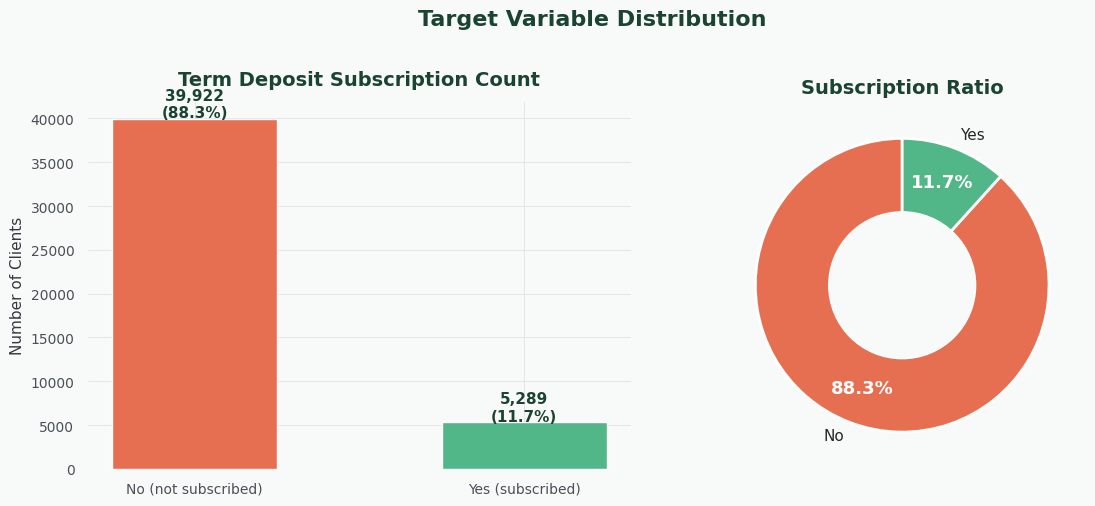

✔  Plot 1 — Target Distribution


In [85]:
# ─── PLOT 1: Target Distribution ─────────────────────────────
counts = df["y"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(["No (not subscribed)","Yes (subscribed)"],
                   counts.values, color=[NEG_COLOR, POS_COLOR],
                   edgecolor="white", width=0.5)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                 f"{v:,}\n({v/len(df)*100:.1f}%)",
                 ha="center", fontsize=11, color=PRIMARY, fontweight="bold")
style_ax(axes[0], "Term Deposit Subscription Count",
         ylabel="Number of Clients", legend=False)

wedges, texts, autos = axes[1].pie(
    counts.values, labels=["No","Yes"],
    autopct="%1.1f%%", startangle=90,
    colors=[NEG_COLOR, POS_COLOR], pctdistance=0.75,
    wedgeprops={"linewidth":2, "edgecolor":"white"})
for t in autos:
    t.set_fontsize(13); t.set_color("white"); t.set_fontweight("bold")
axes[1].add_patch(plt.Circle((0,0), 0.5, fc=BG))
axes[1].set_title("Subscription Ratio", **FTITLE)

plt.suptitle("Target Variable Distribution",
             fontsize=16, fontweight="bold", color=PRIMARY, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT}plot_01_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show(); print("✔  Plot 1 — Target Distribution")

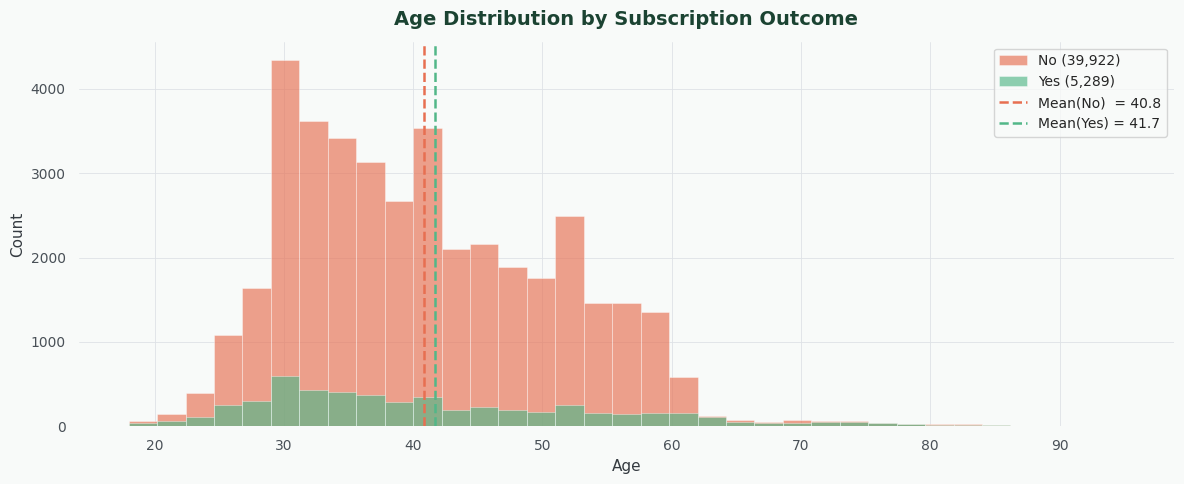

✔  Plot 2 — Age Distribution


In [83]:
# ─── PLOT 2: Age Distribution by Outcome ─────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for label, color, sub in [("No", NEG_COLOR, df[df.y=="no"]["age"]),
                           ("Yes", POS_COLOR, df[df.y=="yes"]["age"])]:
    ax.hist(sub, bins=35, alpha=0.65, color=color,
            label=f"{label} ({len(sub):,})", edgecolor="white", lw=0.4)
ax.axvline(df[df.y=="no"]["age"].mean(), color=NEG_COLOR, ls="--", lw=1.8,
           label=f"Mean(No)  = {df[df.y=='no']['age'].mean():.1f}")
ax.axvline(df[df.y=="yes"]["age"].mean(), color=POS_COLOR, ls="--", lw=1.8,
           label=f"Mean(Yes) = {df[df.y=='yes']['age'].mean():.1f}")
ax.legend(fontsize=10)
style_ax(ax, "Age Distribution by Subscription Outcome",
         xlabel="Age", ylabel="Count")
plt.tight_layout()
plt.savefig(f"{OUT}plot_02_age_distribution.png", dpi=300, bbox_inches="tight")
plt.show(); print("✔  Plot 2 — Age Distribution")

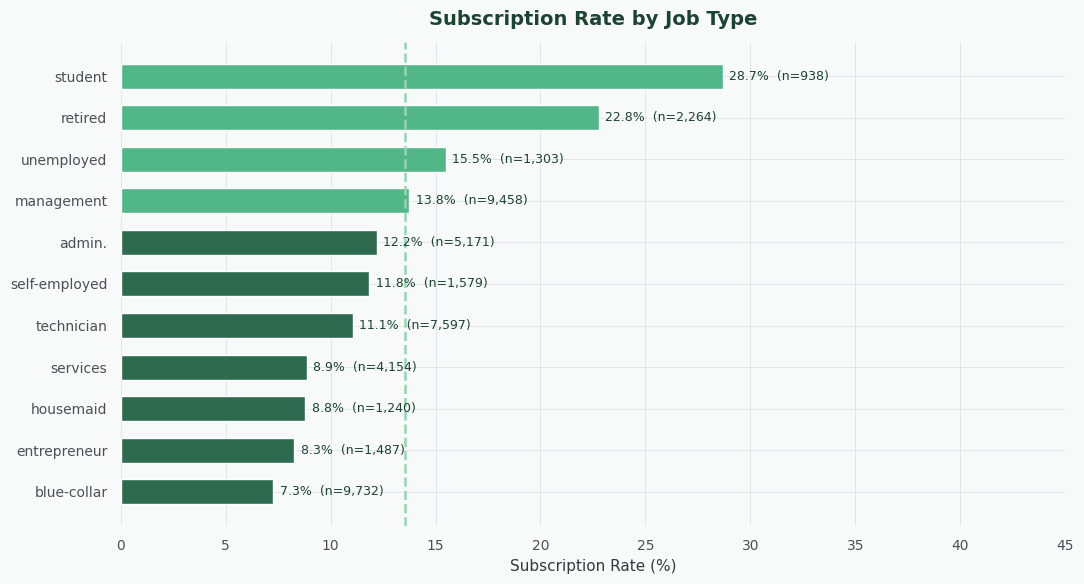

✔  Plot 3 — Subscription by Job


In [45]:
# ─── PLOT 3: Subscription Rate by Job ────────────────────────
job_rate = (df.groupby("job")["y_bin"]
              .agg(["mean","count"])
              .reset_index()
              .rename(columns={"mean":"sub_rate","count":"n"})
              .sort_values("sub_rate", ascending=True))
job_rate = job_rate[job_rate["n"] > 50]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(job_rate["job"], job_rate["sub_rate"]*100,
               color=[POS_COLOR if v > job_rate["sub_rate"].mean()
                      else PALETTE[1] for v in job_rate["sub_rate"]],
               edgecolor="white", height=0.6)
ax.axvline(job_rate["sub_rate"].mean()*100, color=ACCENT,
           ls="--", lw=1.8, label=f"Avg = {job_rate['sub_rate'].mean()*100:.1f}%")
for bar, (_, row) in zip(bars, job_rate.iterrows()):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f"{row['sub_rate']*100:.1f}%  (n={int(row['n']):,})",
            va="center", fontsize=9, color=PRIMARY)
ax.set_xlim(0, 45)
style_ax(ax, "Subscription Rate by Job Type",
         xlabel="Subscription Rate (%)", legend=False)
plt.tight_layout()
plt.savefig(f"{OUT}plot_03_subscription_by_job.png", dpi=150, bbox_inches="tight")
plt.show(); print("✔  Plot 3 — Subscription by Job")

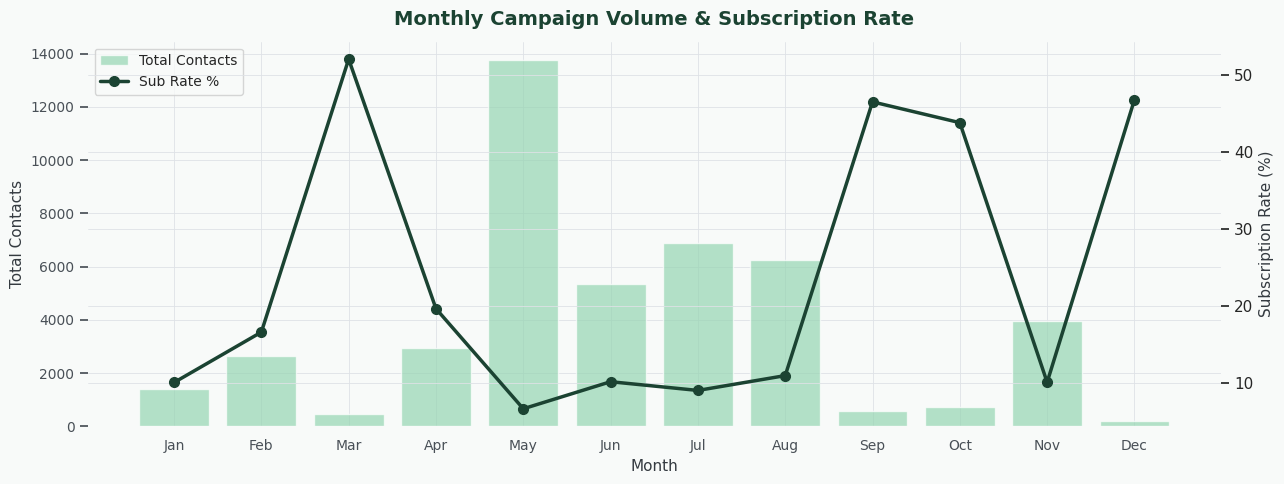

✔  Plot 4 — Monthly Campaign


In [47]:
# ─── PLOT 4: Monthly Campaign Volume & Subscription Rate ──────
monthly = (df.groupby("month_num")
             .agg(total=("y_bin","count"), subscribed=("y_bin","sum"))
             .reset_index())
monthly["rate"] = monthly["subscribed"] / monthly["total"] * 100
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly["month_label"] = monthly["month_num"].apply(lambda x: month_labels[x-1])

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()
ax1.bar(monthly["month_label"], monthly["total"],
        color=ACCENT, alpha=0.7, label="Total Contacts", edgecolor="white")
ax2.plot(monthly["month_label"], monthly["rate"],
         color=PRIMARY, lw=2.5, marker="o", ms=7, label="Sub Rate %")
ax2.set_ylabel("Subscription Rate (%)", **FLABEL)
ax1.set_ylabel("Total Contacts", **FLABEL)
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labs1+labs2, fontsize=10, loc="upper left")
style_ax(ax1, "Monthly Campaign Volume & Subscription Rate",
         xlabel="Month", legend=False)
for sp in ax2.spines.values(): sp.set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUT}plot_04_monthly_campaign.png", dpi=150, bbox_inches="tight")
plt.show(); print("✔  Plot 4 — Monthly Campaign")

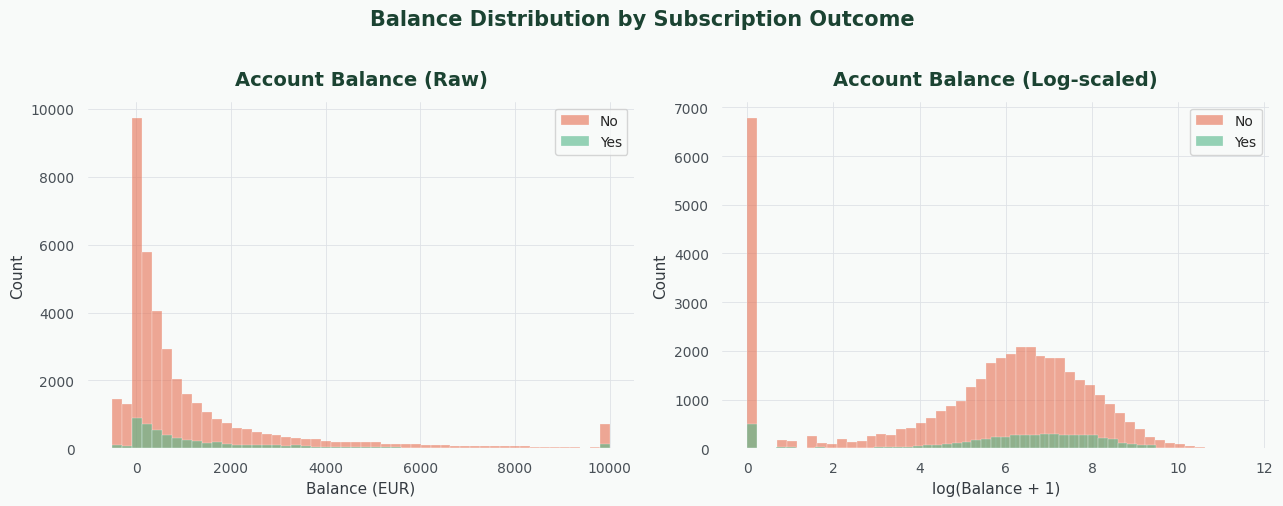

✔  Plot 5 — Balance Distribution


In [49]:
# ─── PLOT 5: Balance Distribution ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for label, color, sub in [("No", NEG_COLOR, df[df.y=="no"]["balance"]),
                           ("Yes", POS_COLOR, df[df.y=="yes"]["balance"])]:
    axes[0].hist(sub.clip(-500, 10000), bins=50, alpha=0.6,
                 color=color, label=label, edgecolor="white", lw=0.3)
axes[0].legend(fontsize=10)
style_ax(axes[0], "Account Balance (Raw)", xlabel="Balance (EUR)", ylabel="Count")

for label, color, sub in [("No", NEG_COLOR, df[df.y=="no"]["balance_log"]),
                           ("Yes", POS_COLOR, df[df.y=="yes"]["balance_log"])]:
    axes[1].hist(sub, bins=50, alpha=0.6, color=color,
                 label=label, edgecolor="white", lw=0.3)
axes[1].legend(fontsize=10)
style_ax(axes[1], "Account Balance (Log-scaled)",
         xlabel="log(Balance + 1)", ylabel="Count")
plt.suptitle("Balance Distribution by Subscription Outcome",
             fontsize=15, fontweight="bold", color=PRIMARY, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT}plot_05_balance_distribution.png", dpi=150, bbox_inches="tight")
plt.show(); print("✔  Plot 5 — Balance Distribution")

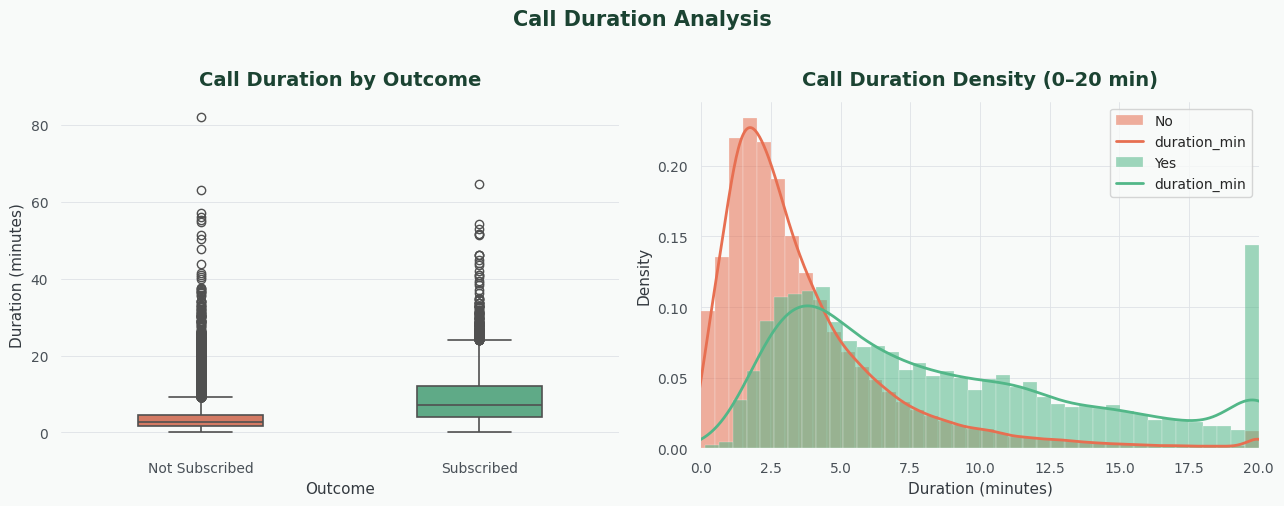

✔  Plot 6 — Duration Analysis


In [51]:
# ─── PLOT 6: Call Duration Analysis ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x="y", y="duration_min", order=["no","yes"],
            palette=[NEG_COLOR, POS_COLOR], width=0.45,
            linewidth=1.2, ax=axes[0])
axes[0].set_xticklabels(["Not Subscribed","Subscribed"])
style_ax(axes[0], "Call Duration by Outcome",
         xlabel="Outcome", ylabel="Duration (minutes)")

for label, color, sub in [("No", NEG_COLOR, df[df.y=="no"]["duration_min"]),
                           ("Yes", POS_COLOR, df[df.y=="yes"]["duration_min"])]:
    axes[1].hist(sub.clip(0,20), bins=40, density=True, alpha=0.55,
                 color=color, label=label, edgecolor="white", lw=0.3)
    sub.clip(0,20).plot.kde(ax=axes[1], color=color, lw=2)
axes[1].set_xlim(0, 20)
axes[1].legend(fontsize=10)
style_ax(axes[1], "Call Duration Density (0–20 min)",
         xlabel="Duration (minutes)", ylabel="Density")
plt.suptitle("Call Duration Analysis",
             fontsize=15, fontweight="bold", color=PRIMARY, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT}plot_06_duration_analysis.png", dpi=150, bbox_inches="tight")
plt.show(); print("✔  Plot 6 — Duration Analysis")

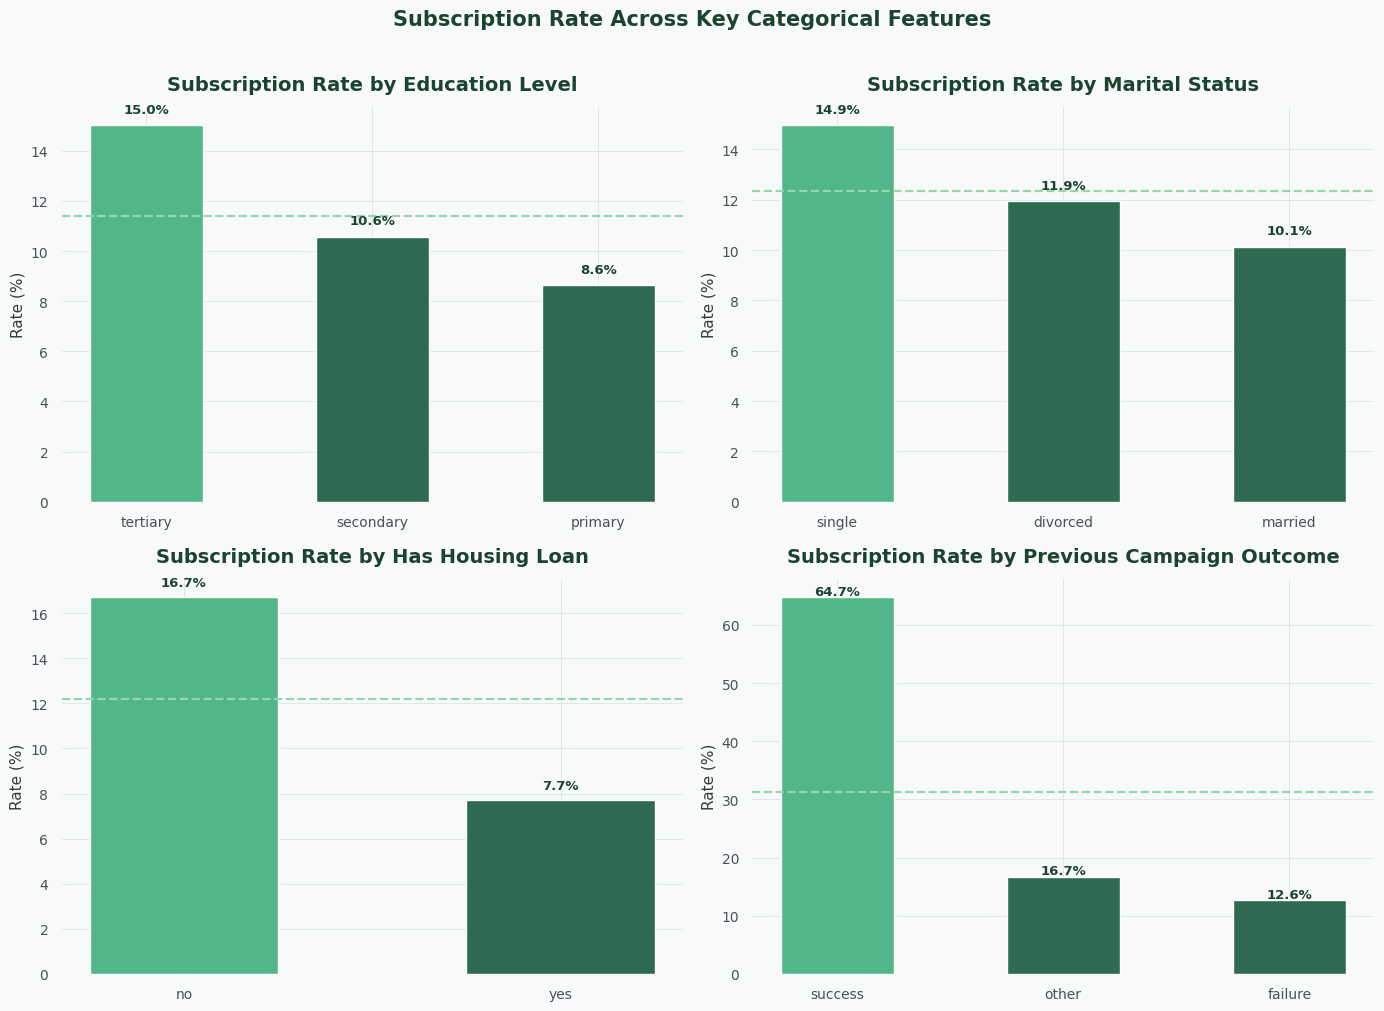

✔  Plot 7 — Categorical Sub Rates


In [53]:
# ─── PLOT 7: Categorical Sub Rates (2×2) ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cat_features = [("education","Education Level"), ("marital","Marital Status"),
                ("housing","Has Housing Loan"), ("poutcome","Previous Campaign Outcome")]
for ax, (col, title) in zip(axes.flatten(), cat_features):
    grp = (df.groupby(col)["y_bin"]
             .agg(["mean","count"])
             .reset_index()
             .rename(columns={"mean":"rate","count":"n"})
             .sort_values("rate", ascending=False))
    bars = ax.bar(grp[col], grp["rate"]*100,
                  color=[POS_COLOR if v > grp["rate"].mean()
                         else PALETTE[1] for v in grp["rate"]],
                  edgecolor="white", width=0.5)
    ax.axhline(grp["rate"].mean()*100, color=ACCENT, ls="--", lw=1.6)
    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{row['rate']*100:.1f}%",
                ha="center", fontsize=9.5, color=PRIMARY, fontweight="bold")
    style_ax(ax, f"Subscription Rate by {title}", ylabel="Rate (%)", legend=False)
plt.suptitle("Subscription Rate Across Key Categorical Features",
             fontsize=15, fontweight="bold", color=PRIMARY, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT}plot_07_categorical_subrates.png", dpi=150, bbox_inches="tight")
plt.show(); print("✔  Plot 7 — Categorical Sub Rates")

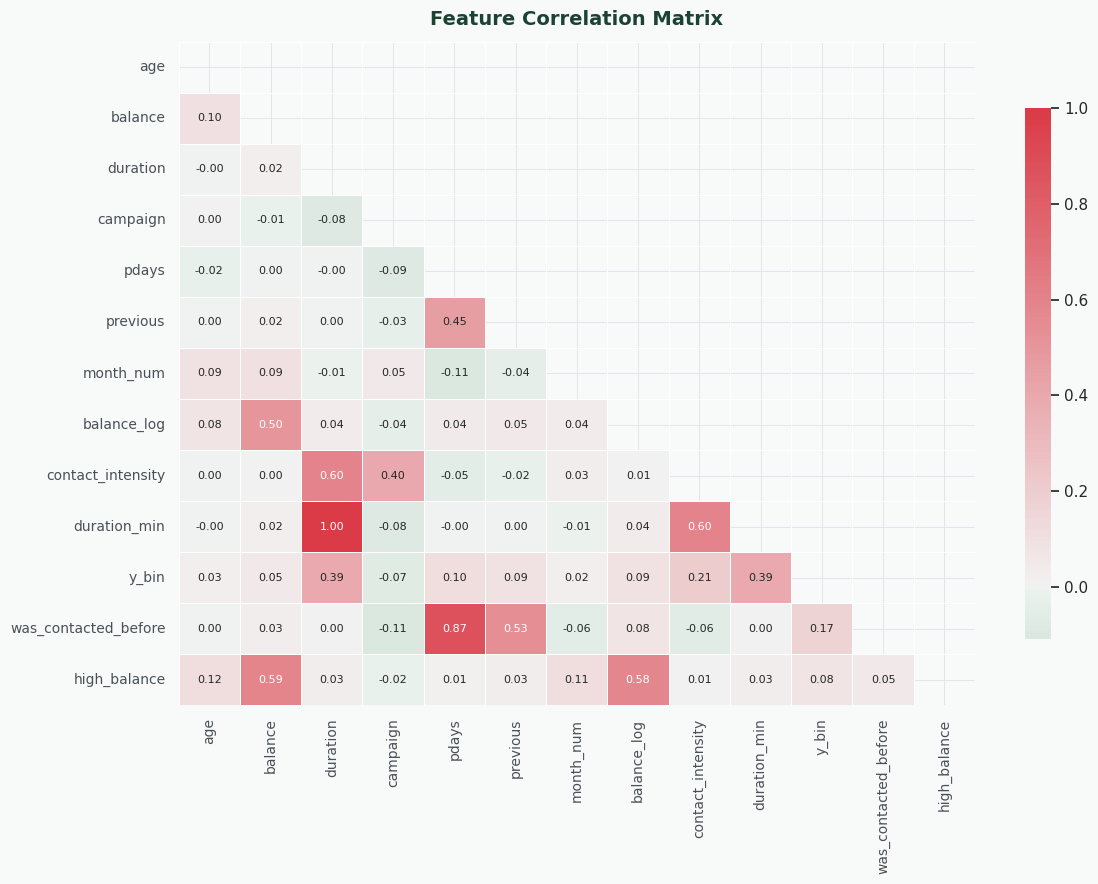

✔  Plot 8 — Correlation Heatmap


In [55]:
# ─── PLOT 8: Correlation Heatmap ─────────────────────────────
num_cols = ["age","balance","duration","campaign","pdays","previous",
            "month_num","balance_log","contact_intensity","duration_min",
            "y_bin","was_contacted_before","high_balance"]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap=sns.diverging_palette(145, 10, as_cmap=True),
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={"shrink":0.8}, annot_kws={"size":8})
style_ax(ax, "Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(f"{OUT}plot_08_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show(); print("✔  Plot 8 — Correlation Heatmap")

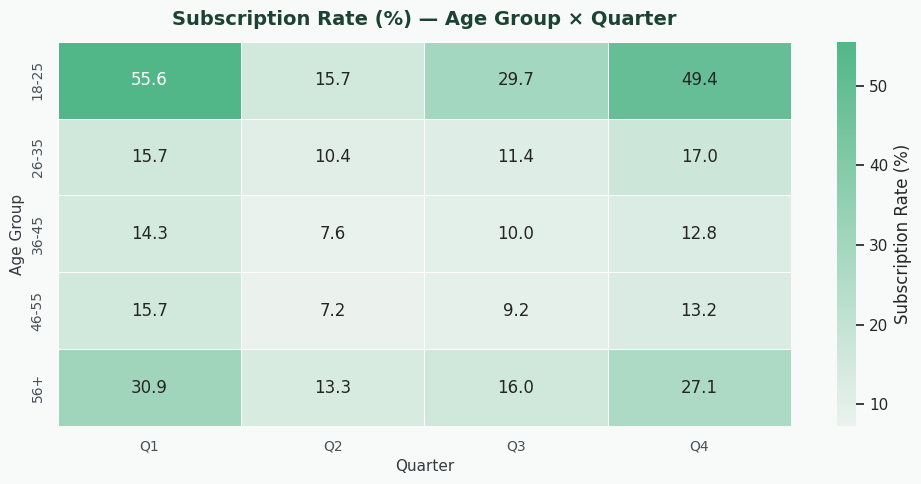

✔  Plot 9 — Age Group × Quarter Heatmap


In [57]:
# ─── PLOT 9: Age Group × Quarter Heatmap ─────────────────────
pivot_hm = (df.dropna(subset=["age_group","quarter"])
              .groupby(["age_group","quarter"])["y_bin"]
              .mean() * 100).unstack()
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_hm, annot=True, fmt=".1f",
            cmap=sns.light_palette(POS_COLOR, as_cmap=True),
            linewidths=0.5, ax=ax,
            cbar_kws={"label":"Subscription Rate (%)"})
style_ax(ax, "Subscription Rate (%) — Age Group × Quarter",
         xlabel="Quarter", ylabel="Age Group")
plt.tight_layout()
plt.savefig(f"{OUT}plot_09_agegroup_quarter_heatmap.png", dpi=150, bbox_inches="tight")
plt.show(); print("✔  Plot 9 — Age Group × Quarter Heatmap")

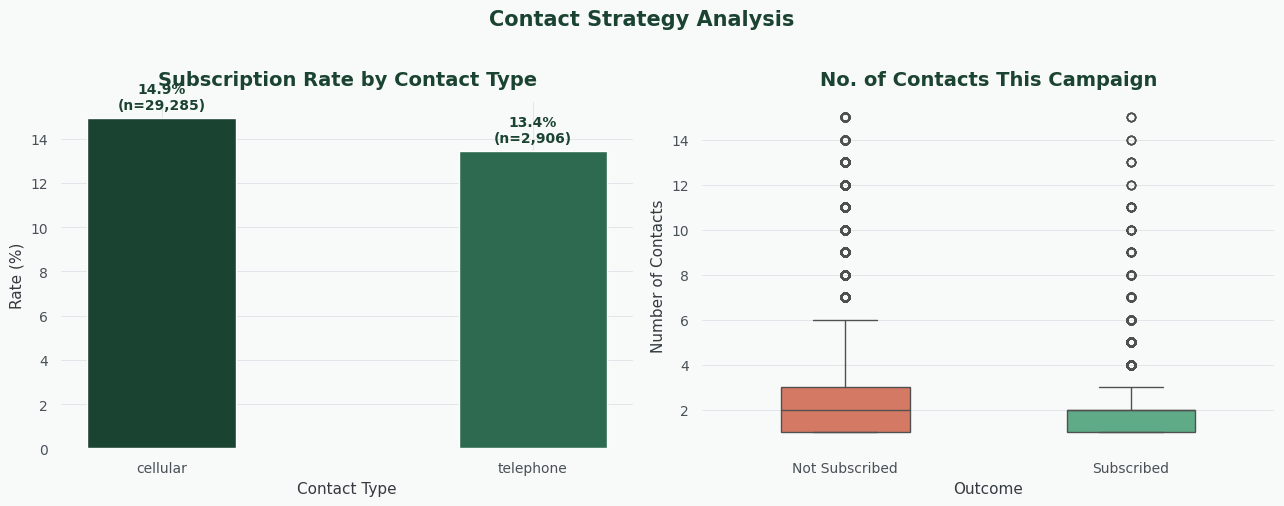

✔  Plot 10 — Contact Analysis


In [59]:
# ─── PLOT 10: Contact Strategy Analysis ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
contact_rate = (df.groupby("contact")["y_bin"]
                  .agg(["mean","count"]).reset_index()
                  .rename(columns={"mean":"rate","count":"n"}))
bars = axes[0].bar(contact_rate["contact"], contact_rate["rate"]*100,
                   color=PALETTE[:3], edgecolor="white", width=0.4)
for bar, (_, row) in zip(bars, contact_rate.iterrows()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                 f"{row['rate']*100:.1f}%\n(n={int(row['n']):,})",
                 ha="center", fontsize=10, color=PRIMARY, fontweight="bold")
style_ax(axes[0], "Subscription Rate by Contact Type",
         xlabel="Contact Type", ylabel="Rate (%)")

sns.boxplot(data=df[df["campaign"]<=15], x="y", y="campaign",
            order=["no","yes"], palette=[NEG_COLOR, POS_COLOR],
            width=0.45, ax=axes[1])
axes[1].set_xticklabels(["Not Subscribed","Subscribed"])
style_ax(axes[1], "No. of Contacts This Campaign",
         xlabel="Outcome", ylabel="Number of Contacts")
plt.suptitle("Contact Strategy Analysis",
             fontsize=15, fontweight="bold", color=PRIMARY, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT}plot_10_contact_analysis.png", dpi=150, bbox_inches="tight")
plt.show(); print("✔  Plot 10 — Contact Analysis")